### Import requirements

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np

### Read input and remove noises

In [2]:
data = pd.read_csv('/kaggle/input/mos-qoe/output.csv')
for i in range(len(data)):
    if data['delay_qos'][i] == -1000 \
    or data['delay_qos'][i] == 0 or data['avg_bitrate'][i] == 0:
        data = data.drop([i])
        continue
    if data['jitter'][i] == 0:
        data['jitter'][i] = 1
    if data['jitter'][i] == -1000:
        data['jitter'][i] = 1

data['mos'] = data['mos'] / 100

print (str(len(data)) + ' Data Loaded Successfully')


20411 Data Loaded Successfully


In [3]:
data.describe()

,mos,throughput,avg_bitrate,delay_qos,jitter,packet_loss
count,20411.000000,2.041100e+04,20411.000000,20411.000000,20411.000000,20411.000000
mean,0.024294,1.384516e+06,1359.615109,207.731419,34.031993,1002.253687
std,0.008760,2.909504e+06,3089.283138,284.263992,52.685542,1250.134267
min,0.011300,1.131500e+04,10.000000,1.000000,1.000000,0.000000
25%,0.017200,3.069700e+05,310.000000,86.000000,9.000000,0.000000
50%,0.020900,4.784080e+05,660.000000,134.000000,18.000000,1000.000000
75%,0.030600,9.258890e+05,1310.000000,187.000000,36.000000,2000.000000
max,0.048000,4.842488e+07,49310.000000,4468.000000,897.000000,8000.000000


### Feature engineering

In [4]:
# Add more features: Derive new features like interactions (e.g. throughput * delay), polynomials, log transforms etc. More predictive features can reduce MSE.
data['delay_log'] = np.log(data['delay_qos']+1) 

data['bitrate_log'] = np.log(data['avg_bitrate']+1)

data['packet_loss_squared'] = data['packet_loss'] ** 2

data['throughput_jitter'] = data['throughput'] * data['jitter']

data['delay_jitter'] = data['delay_qos'] * data['jitter']

data['loss_rate'] =  data['avg_bitrate'] / (data['packet_loss'] + 1)


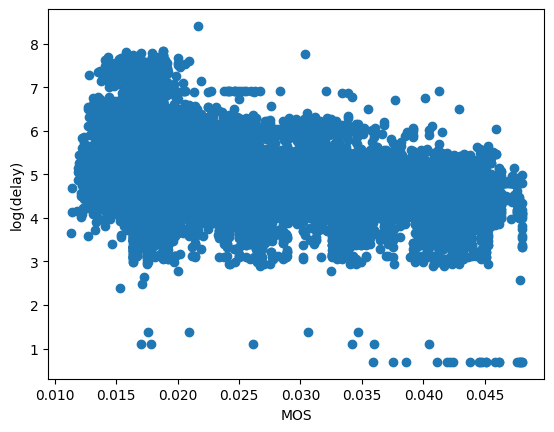

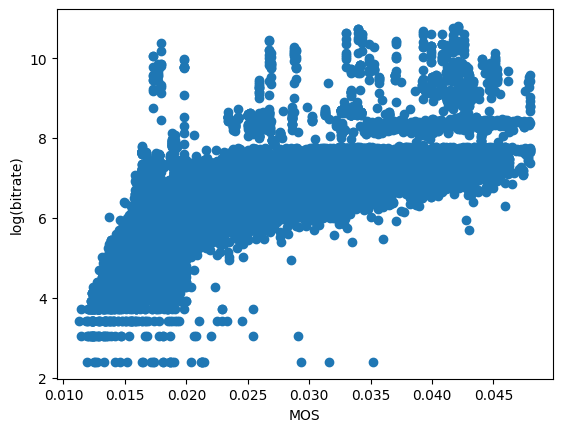

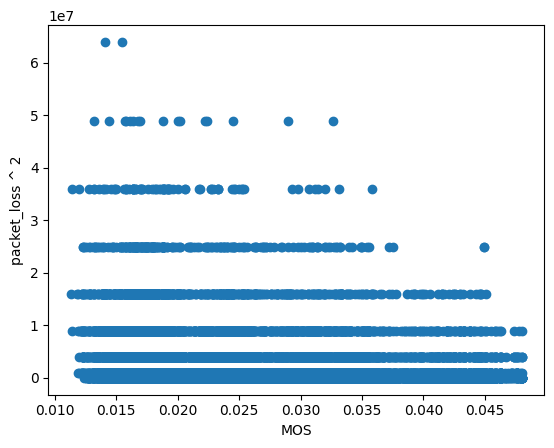

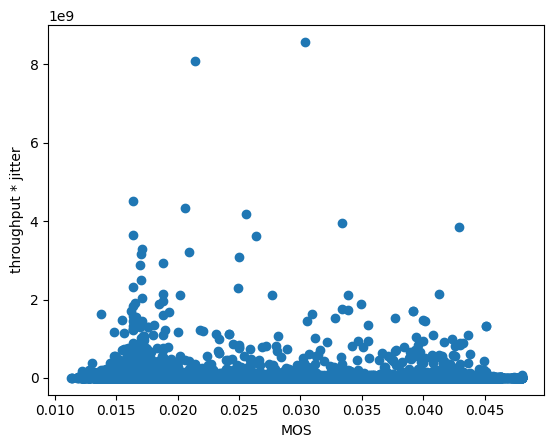

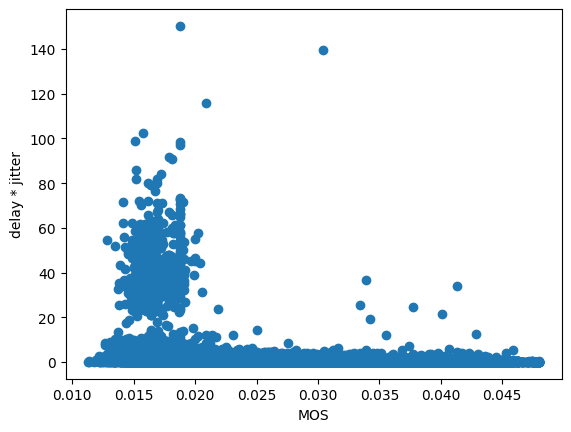

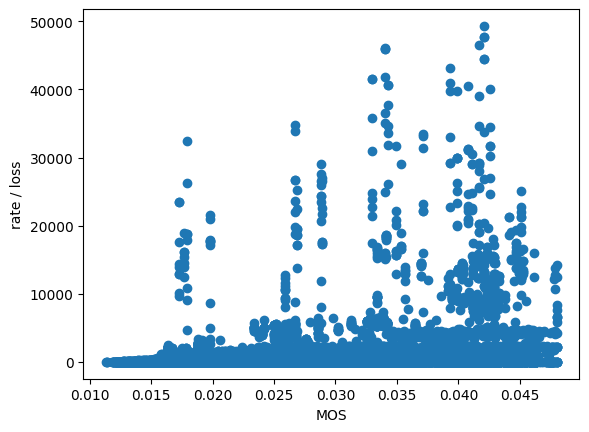

In [5]:
plt.xlabel('MOS')
plt.scatter(data['mos'],data['delay_log'])
plt.ylabel('log(delay)')
plt.xlabel('MOS')
plt.show("r+")
plt.scatter(data['mos'],data['bitrate_log'])
plt.ylabel('log(bitrate)')
plt.xlabel('MOS')
plt.show()
plt.scatter(data['mos'],data['packet_loss_squared'])
plt.ylabel('packet_loss ^ 2')
plt.xlabel('MOS')
plt.show()
plt.scatter(data['mos'],data['throughput_jitter'])
plt.ylabel('throughput * jitter')
plt.xlabel('MOS')
plt.show()
plt.scatter(data['mos'], data['delay_jitter'] / 100 / 100)
plt.ylabel('delay * jitter')
plt.xlabel('MOS')
plt.show()

plt.scatter(data['mos'], data['loss_rate'])
plt.ylabel('rate / loss')
plt.xlabel('MOS')
plt.show()

### Import requirements to train and test model

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import normalize


### Scores with old features (without feature engineering)

In [7]:
# Train model with old features *****

# Pure Features
X = data.drop('mos', axis=1)

X = data[['delay_qos','avg_bitrate','jitter', 'throughput','packet_loss']] 
y = data['mos']

X = normalize(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor() 
rf.fit(X_train, y_train)


rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
print("Old MSE:", rf_mse)
print("New RMSE:", rf_rmse)

rf_r2 = r2_score(y_test, rf_pred) 
rf_mae = mean_absolute_error(y_test, rf_pred)

print("R-squared:", rf_r2)
print("MAE:", rf_mae)

Old MSE: 2.8306414911094787e-05
New RMSE: 0.005320377327887073
R-squared: 0.6251601624832366
MAE: 0.003878927259368111


### Final scores (with feature engineering)

In [8]:
# Train model with new features *****



X = data[['delay_log', 'bitrate_log', 'throughput_jitter', 'delay_jitter','loss_rate', ]] 
y = data['mos']




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




rf = RandomForestRegressor(n_estimators=600, max_depth=48, max_features=0.58)
rf.fit(X, y)

# Evaluate

rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("New MSE:", rf_mse)
print("New RMSE:", rf_rmse)


rf_r2 = r2_score(y_test, rf_pred) 
rf_mae = mean_absolute_error(y_test, rf_pred)


print("R-squared:", rf_r2)
print("MAE:", rf_mae)

New MSE: 3.080049605837349e-06
New RMSE: 0.0017550070101960702
R-squared: 0.9592132985607046
MAE: 0.0012476259082374154
